# (urbanair-dm) Comparison (minimal working example)

Comparison methods for observation products, as well as for observations and model simulations. 

Creator: Matthias Zeeman, University of Freiburg, for the UrbanAIR project.

### Included in this Notebook

1. Methods for ETL from N-dimensional source data (intermediate, final) (**L2**, **L1**)

In [1]:
import glob
import io
import itertools
import json
import math
import os
import pickle
import re
import sys
import warnings
from collections import OrderedDict, defaultdict
from pathlib import Path

import bottleneck
import markdown
import mergedeep
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import xarray as xr
import zarr
from IPython.display import HTML
from IPython.display import Image as IPImage
from PIL import Image
from plotly.express.colors import sample_colorscale
from plotly.subplots import make_subplots
from tqdm.notebook import tqdm

In [2]:
sys.path.append(str(Path("../src/").resolve()))
from urbanair_dm_lib import *

In [3]:
# set a static renderer for notebook previews on github
import plotly.io as pio

png_renderer = pio.renderers["png"]
png_renderer.scale = 1

# for interactive plots, set default to 'notebook_connected' or 'browser'
pio.renderers.default = "png"

In [4]:
def get_datatree_dict(dv_dict):
    dtd = {
        k: v["data"]["func"](*v["data"]["kargs"], **v["data"]["kwargs"])
        for k, v in dv_dict.items()
    }
    return dtd


def get_dataarray_dict(dv_dict, dtd):
    # plot data
    dad = {}
    for key in list(dv_dict.keys()):
        dad[key] = datatree_to_dataarray(dtd, dv_dict, key)
    return dad

In [5]:
def get_masked_dataarray_dict(dv_dict, dad, mv_keys):

    dam = {}
    damd = {}
    for key in dad:
        if key in mv_keys:
            continue

        nx = dv_dict[key]["x"]["name"]
        ny = dv_dict[key]["y"]["name"]
        da = dad[key]

        # x: infer freq
        da[nx] = pd.to_datetime(da[nx])
        dt = pd.infer_freq(da[nx])
        if not dt:
            dt = (
                pd.to_datetime(da[nx].astype(str))
                .diff()
                .median()
                .round(pd.to_timedelta("1s"))
            )
            dt = pd.tseries.frequencies.to_offset(dt).freqstr

            da = da.resample(**{nx: dt}).mean()

        print(f"{key:<30} x: {nx:<20} y: {ny:<20} freq: {dt}")

        # foreach filter
        for mey in mv_keys:
            # align x
            mx = dv_dict[mey]["x"]["name"]
            dm = dad[mey].copy()
            dm = dm.squeeze().drop_vars([n for n in dm.coords if not n in dm.indexes])
            dm = dm.rename({mx: nx})
            dm = (
                dm.dropna(nx)
                .resample({nx: dt})
                .interpolate(kind="linear", fill_value="extrapolate")
            )
            dm = dm.expand_dims({ny: da.sizes[ny]}).assign_coords(coords={ny: da[ny]})
            dm, da = xr.align(dm, da, join="right", fill_value=333)

            # align y
            bool1 = (
                np.logical_not(dv_dict[mey]["mask"]["inverse"])
                if "mask" in dv_dict[mey]
                else True
            )
            dm = xr.where(xr.ufuncs.less_equal(da[ny],dm), bool1, np.logical_not(bool1))
            da = xr.where(dm, da, np.nan)

            dam[f"{key} || {mey}"] = dm

        damd[f"{key}"] = da

        # plot_da(dm, **mask_args).update_layout(**mask_opts).show()
        # plot_da(da).show()
    return (dam, damd)

In [6]:
def get_fig_dataarray_dict(dv_dict, dad, px_opts, pc_opts):
    # plots
    fh = {}
    for key in list(dad.keys()):
        fh[key] = plot_da(dad[key], **px_opts)
        fh[key].update_layout(**pc_opts)
        fh[key].update_xaxes(range=unslice(x_slice), autorange=False)
        fh[key].update_yaxes(range=unslice(y_slice), autorange=False)

    return fh


def put_fig_dataarray_dict(dv_dict, fhd, sep=r" || ", export=False, **kwargs):
    # plots
    tfx = kwargs.get("time_bounds", "time_range")
    pfx = kwargs.get("file_name", "fig_x")
    loc = f"{kwargs['station_id']}" if "station_id" in kwargs else ""

    for idx, fig in dict(sorted(fhd.items())).items():
        keys = idx.split(sep)
        key = f"{keys[0]}/{dv_dict[keys[0]]['z']['name']}"
        mey = f"{keys[1]}/{dv_dict[keys[1]]['z']['name']}" if len(keys) > 1 else ""

        title = f"{key}{sep if len(mey)>0 else ""}{mey} {"at " + loc if len(loc)>0 else loc}"
        sfx = kwargs.get("suffix", "_mask") if len(mey) > 0 else ""

        # update
        fig.update_layout(title=title, title_font_size=12)
        fig.update_layout(
            **{k: v for k, v in kwargs.items() if k in ["height", "width"]}
        )

        # export
        if export:
            fig_id = f"{key}{sfx},{tfx},{loc}"
            fig_id = fig_id.replace("/", "-")
    
            fig_file = f"../tmp/{pfx}_set({fig_id}).svg"
            print(fig_file)
            fig.write_image(fig_file, scale=2)

        # show
        fig.show()        

In [7]:
def dataclass_defaults(**kwargs):
    opts_default = dict(
        station_id="PALUPD",
        x_slice=slice("2023-08-21 04:00:00", "2023-08-21 22:00:00"),
        y_slice=slice(200, 2000),
    )
    opts = {**opts_default, **kwargs}

    px_args = dict(
        range_color=[-1, 1],
        color_continuous_scale="RdBu_r",
    )

    # data variables
    dv_dict = {
        "observed/alc/L2B/station": dict(
            data=dict(
                func=dataset_to_datatree,
                kargs=[["../data/ALC/L2B/", "ALC_L2B_data_consolidated.nc"]],
                kwargs=dict(engine="netcdf4"),
            ),
            x={
                "name": "time",
                "sel": opts["x_slice"],
            },
            y={
                "name": "cell_z_bounds",
            },
            z={
                "name": "MLH",
                "path": f"/{opts['station_id'][2:]}",
                "isel": dict(station=0),
            },
            mask=dict(inverse=False),
        ),
        "observed/dwl/L1/station": dict(
            data=dict(
                func=xr.open_datatree,
                kargs=["../data/DWL/L1/DWL_L1_data_consolidated.zarr.zip"],
                kwargs=dict(engine="zarr"),
            ),
            x={
                "name": "time",
                "sel": opts["x_slice"],
            },
            y={
                "name": "cell_z_bounds",
                "sel": opts["y_slice"],
            },
            z={
                "name": "w",
                "path": f"/station/{opts['station_id'][2:]}",
                "isel": dict(station=0, system=0, attributes=0),
            },
        ),
        "observed/dwl/L2/mesonh": dict(
            data=dict(
                func=dataset_to_datatree,
                kargs=[["../data/DWL/L2/", "DWL_L2_data_consolidated.zarr.zip"]],
                kwargs=dict(engine="zarr"),
            ),
            x={
                "name": "time",
                "sel": opts["x_slice"],
            },
            y={
                "name": "cell_z_bounds",
                "swap_coord": ("cell_id", "cell_z_bounds"),
                "sel": opts["y_slice"],
            },
            z={
                "name": "w_mean",
                "path": f"/{opts['station_id'][2:]}",
                "sel": dict(
                    channel_id=3,  # ...  model configuration (3=MESONH model)
                    cell_mode=1,  # ... sampling mode (1=half-level)
                    channel_mode=0,  # ... channel from stats computations (0=stare,1=vad)
                ),
            },
        ),
        "observed/dwl/L1/mesonh": dict(
            data=dict(
                func=xr.open_datatree,
                kargs=["../data/DWL/L1/DWL_L1_data_consolidated.zarr.zip"],
                kwargs=dict(engine="zarr"),
            ),
            x={
                "name": "time",
                "sel": opts["x_slice"],
                #"resample": "90s",
            },
            y={
                "name": "cell_z_bounds",
                "sel": opts["y_slice"],
            },
            z={
                "name": "w",
                "path": f"/mesonh/{opts['station_id'][2:]}",
                "isel": dict(station=0, system=0, attributes=0),
            },
        ),
        "modelled/mesonh/L1": dict(
            data=dict(
                func=xr.open_datatree,
                kargs=["../data/repositories/Wurtz_2025/LES_.2.SEG01.000.nc"],
                kwargs=dict(engine="netcdf4"),
            ),
            x={
                "name": "time_profiler",
                "sel": opts["x_slice"],
            },
            y={
                "name": "level_w",
                "sel": opts["y_slice"],
            },
            z={
                "name": "W",
                "path": f"/Profilers/{opts['station_id'][2:]}/Vertical_profile",
                "sel": {},
            },
        ),
    }

    # mask variables
    mv_keys = [k for k in dv_dict if "mask" in dv_dict[k]]  # "observed/alc/L2B/station"
    mv_args, mv_opts = plot_da_template("mask")

    return (dv_dict, px_args, opts, mv_keys, mv_args, mv_opts)

In [8]:
# Global selection and configuration
station_id = "PACHEM"
x_slice = slice("2023-08-21 04:00:00", "2023-08-21 22:00:00")
y_slice = slice(150, 2150)

# wrap
global_opts = dict(station_id=station_id, x_slice=x_slice, y_slice=y_slice)

# MAIN

## Attach data

In [9]:
dv_dict, _, _, mv_keys, mv_args, mv_opts = dataclass_defaults(**global_opts)
dtd = get_datatree_dict(dv_dict)

Found 1 files
dataset_to_datatree: ['L2B', 'set(fr.paris,ALC,2022_2024)']
Found 1 files
dataset_to_datatree: ['L2', 'set(fr.paris,DWL,2022_2024)']


In [10]:
for p in list(dtd.keys()):
    print(f"catalogue item: '{p}'")

catalogue item: 'observed/alc/L2B/station'
catalogue item: 'observed/dwl/L1/station'
catalogue item: 'observed/dwl/L2/mesonh'
catalogue item: 'observed/dwl/L1/mesonh'
catalogue item: 'modelled/mesonh/L1'


## Cases

### Vertical air velocity

In [11]:
# data var configuration
dv_dict, px_opts, opts, _, _, _ = dataclass_defaults(**global_opts)
dv_opts = {}
dv_dict = mergedeep.merge({}, dv_dict, dv_opts)
_, pc_opts = plot_da_template("w")

##### No mask

In [12]:
dad = get_dataarray_dict(dv_dict, dtd)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [ ]:
fhd = get_fig_dataarray_dict(dv_dict, dad, px_opts, pc_opts)
put_fig_dataarray_dict(dv_dict, fhd, file_name="fig_2", station_id=station_id)

##### Mask(ed)

In [13]:
dam, damd = get_masked_dataarray_dict(dv_dict, dad, mv_keys)

observed/dwl/L1/station        x: time                 y: cell_z_bounds        freq: 3s
observed/dwl/L2/mesonh         x: time                 y: cell_z_bounds        freq: 10min
observed/dwl/L1/mesonh         x: time                 y: cell_z_bounds        freq: 3s
modelled/mesonh/L1             x: time_profiler        y: level_w              freq: 750ms


In [ ]:
fhd = get_fig_dataarray_dict(dv_dict, damd, px_opts, pc_opts)
put_fig_dataarray_dict(dv_dict, fhd, file_name="fig_2", station_id=station_id)

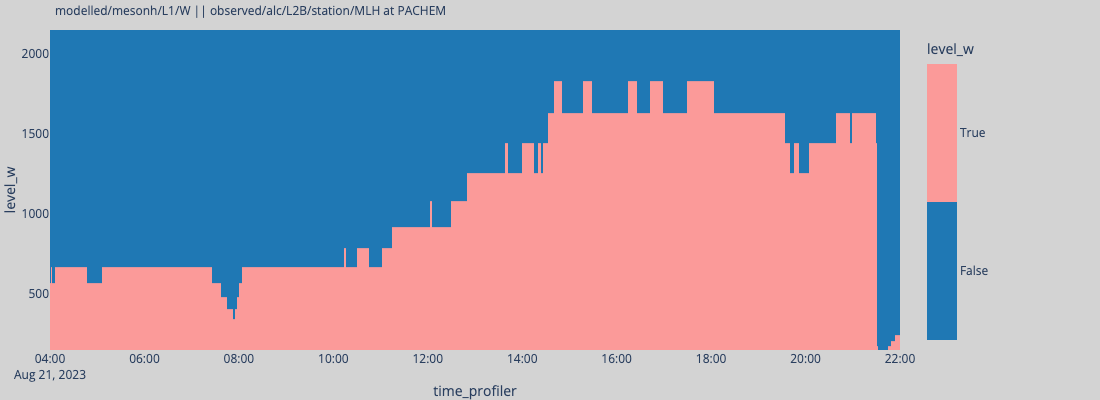

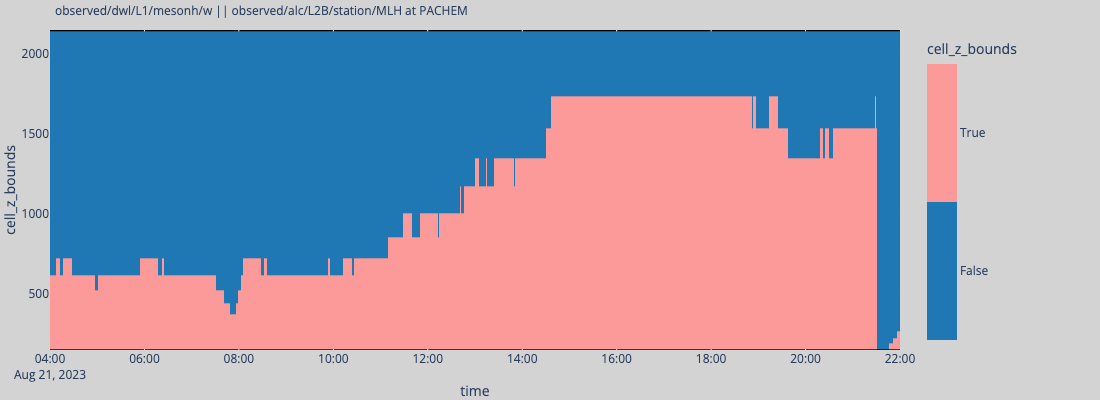

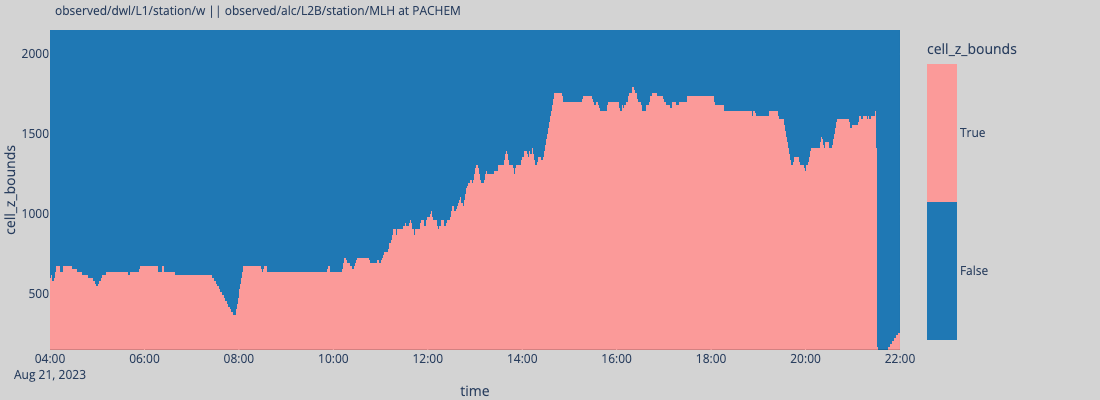

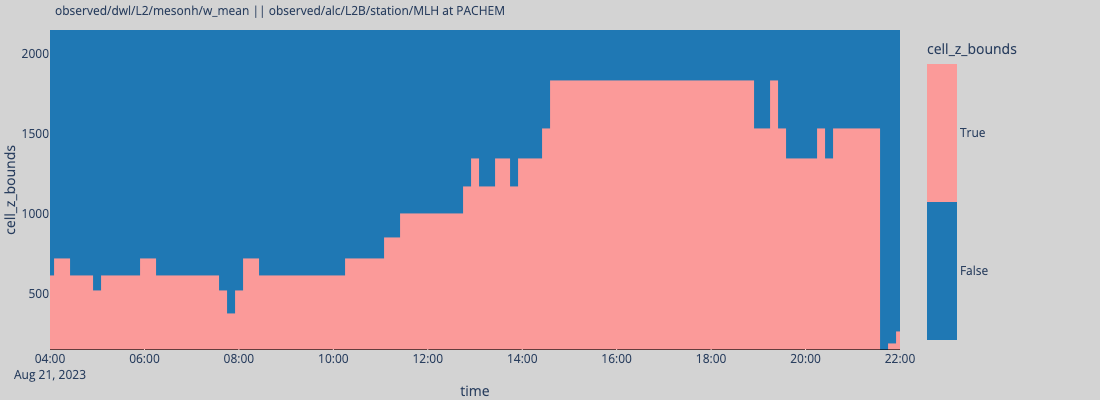

In [14]:
fhd = get_fig_dataarray_dict(dv_dict, dam, mv_args, mv_opts)
put_fig_dataarray_dict(dv_dict, fhd, file_name="fig_2", station_id=station_id)

### Wind direction

In [ ]:
# wind dir
dv_dict, px_opts, opts, _, _, _ = dataclass_defaults(
    station_id=station_id, x_slice=x_slice, y_slice=y_slice
)
dv_opts = {
    "modelled/mesonh/L1": dict(
        z={"name": "DD"},
        y={"name": "level"},
    ),
    "observed/dwl/L2/mesonh": dict(
        z={
            "name": "wdir",
            "sel": dict(
                channel_id=3,  # ...  model configuration (3=MESONH model)
                cell_mode=1,  # ... sampling mode (1=half-level)
                channel_mode=1,  # ... channel from stats computations (0=stare,1=vad)
            ),
        },
    ),
}
dv_dict = mergedeep.merge({}, dv_dict, dv_opts)
dv_dict = {k: v for k, v in dv_dict.items() if k in dv_opts or k in mv_keys}

px_opts, pc_opts = plot_da_template("wind_direction", reverse_colors=True)

##### No mask

In [ ]:
dad = get_dataarray_dict(dv_dict, dtd)

In [ ]:
fhd = get_fig_dataarray_dict(dv_dict, dad, px_opts, pc_opts)
put_fig_dataarray_dict(dv_dict, fhd, file_name="fig_2", station_id=station_id)

##### Mask(ed)

In [ ]:
dam, damd = get_masked_dataarray_dict(dv_dict, dad, mv_keys)

In [ ]:
fhd = get_fig_dataarray_dict(dv_dict, damd, px_opts, pc_opts)
put_fig_dataarray_dict(dv_dict, fhd, file_name="fig_2", station_id=station_id)

In [ ]:
fhd = get_fig_dataarray_dict(dv_dict, dam, mv_args, mv_opts)
put_fig_dataarray_dict(dv_dict, fhd, file_name="fig_2", station_id=station_id)

# Wind speed

In [ ]:
# data var configuration
dv_dict, px_opts, opts, _, _, _ = dataclass_defaults(
    station_id=station_id, x_slice=x_slice, y_slice=y_slice
)
dv_opts = {
    "modelled/mesonh/L1": dict(
        z={"name": "FF"},
        y={"name": "level"},
    ),
    "observed/dwl/L2/mesonh": dict(
        z={
            "name": "ws",
            "sel": dict(
                channel_id=3,  # ...  model configuration (3=MESONH model)
                cell_mode=1,  # ... sampling mode (1=half-level)
                channel_mode=1,  # ... channel from stats computations (0=stare,1=vad)
            ),
        },
    ),
}
dv_dict = mergedeep.merge({}, dv_dict, dv_opts)
dv_dict = {k: v for k, v in dv_dict.items() if k in dv_opts or k in mv_keys}

px_opts, pc_opts = plot_da_template("FF", reverse_colors=False)

##### No mask

In [ ]:
dad = get_dataarray_dict(dv_dict, dtd)

In [ ]:
fhd = get_fig_dataarray_dict(dv_dict, dad, px_opts, pc_opts)
put_fig_dataarray_dict(dv_dict, fhd, file_name="fig_2", station_id=station_id)

##### Mask(ed)

In [ ]:
dam, damd = get_masked_dataarray_dict(dv_dict, dad, mv_keys)

In [ ]:
fhd = get_fig_dataarray_dict(dv_dict, damd, px_opts, pc_opts)
put_fig_dataarray_dict(dv_dict, fhd, file_name="fig_2", station_id=station_id)

In [ ]:
fhd = get_fig_dataarray_dict(dv_dict, dam, mv_args, mv_opts)
put_fig_dataarray_dict(dv_dict, fhd, file_name="fig_2", station_id=station_id)

### Windrose

##### Observed

In [ ]:
# data var configuration
dv_opts1 = {
    "observed/dwl/L2/mesonh": dict(
        z={
            "name": "ws",
            "sel": dict(
                channel_id=3,  # ...  model configuration (3=MESONH model)
                cell_mode=1,  # ... sampling mode (1=half-level)
                channel_mode=1,  # ... channel from stats computations (0=stare,1=vad)
            ),
        },
    ),
}
dv_opts2 = {
    "observed/dwl/L2/mesonh": dict(
        z={
            "name": "wdir",
            "sel": dict(
                channel_id=3,  # ...  model configuration (3=MESONH model)
                cell_mode=1,  # ... sampling mode (1=half-level)
                channel_mode=1,  # ... channel from stats computations (0=stare,1=vad)
            ),
        },
    ),
}

In [ ]:
fhd, opd = plot_dt_windrose(
    dv_opts1, dv_opts2, x_delta="6h", station_id_list=[station_id]
)
put_fig_dataarray_dict(
    dv_opts1, fhd, file_name="fig_3", station_id=station_id, time_bounds="6h"
)

In [ ]:
fhd, opd = plot_dt_windrose(
    dv_opts1,
    dv_opts2,
    station_id_list=[station_id],
    x_range=["2023-08-21 12:00:00", "2023-08-21 16:59:59"],
    x_delta="1h",
)
put_fig_dataarray_dict(
    dv_opts1, fhd, file_name="fig_3", station_id=station_id, time_bounds="1h"
)

##### Modeled

In [ ]:
# data var configuration
dv_opts1 = {
    "modelled/mesonh/L1": dict(
        z={"name": "FF"},
        y={"name": "level"},
    ),
}
dv_opts2 = {
    "modelled/mesonh/L1": dict(
        z={"name": "DD"},
        y={"name": "level"},
    ),
}

In [ ]:
fhd, opd = plot_dt_windrose(
    dv_opts1, dv_opts2, x_delta="6h", station_id_list=[station_id]
)
put_fig_dataarray_dict(
    dv_opts1, fhd, file_name="fig_3", station_id=station_id, time_bounds="6h"
)

In [ ]:
fhd, opd = plot_dt_windrose(
    dv_opts1,
    dv_opts2,
    station_id_list=[station_id],
    x_range=["2023-08-21 12:00:00", "2023-08-21 16:59:59"],
    x_delta="1h",
)
put_fig_dataarray_dict(
    dv_opts1, fhd, file_name="fig_3", station_id=station_id, time_bounds="1h"
)

### PDF / CDF

In [ ]:
# data var configuration
dv_dict, px_opts, opts, _, _, _ = dataclass_defaults(
    station_id=station_id,
    x_slice=slice("2023-08-21 04:00:00", "2023-08-21 22:00:00"),
    y_slice=y_slice,
)
dv_opts = {}
dv_dict = mergedeep.merge({}, dv_dict, dv_opts)
_, pc_opts = plot_da_template("w")

##### No mask

In [ ]:
dad = get_dataarray_dict(dv_dict, dtd)

##### Mask(ed)

In [ ]:
dam, damd = get_masked_dataarray_dict(dv_dict, dad, mv_keys)

In [ ]:
fhd = plot_da_dist(
    dv_dict,
    damd,
    methods=["PDF", "CDF"],    
    orientation="h",    
    y_range=[-5, 5],
    group="< MLH",
)
put_fig_dataarray_dict(
    dv_dict, fhd, file_name="fig_4", station_id=station_id, time_bounds="24h"
)

In [ ]:
fhd = plot_da_quantile(
    dv_dict,
    damd,
)
put_fig_dataarray_dict(
    dv_dict, fhd, file_name="fig_5", station_id=station_id, time_bounds="24h"
)

### Other

In [ ]:
def filter_example():
    # apply filter
    da = xr.where(ds["quality_FLAG"] == 0, ds["MLH"], np.nan)

    # interpolate
    da = (
        da.dropna("time")
        .resample(time="10min")
        .interpolate(kind="linear", fill_value="extrapolate")
    )
    da.plot()

In [ ]:
def mask_example():
    ds = xr.Dataset(
        coords=dict(
            time=np.arange(10),
            z=np.arange(10),
        ),
        data_vars=dict(
            var=(["time"], np.sin(np.arange(10)) * 2 + 4),
            var_mask=(["time", "z"], np.full([10, 10], False)),
        ),
    )
    ds["var_mask"] = xr.where(ds["z"] < ds["var"], True, ds["var_mask"])
    ds["var_mask"].plot()

In [ ]:
HTML(hello_world())